In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'hw1'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from hw1.neuron import train_neuron, train_neuron_with_optimizer
from hw1.autograd import Node
from hw1.optimizers import AdamW

torch.manual_seed(42)
np.random.seed(42)




## 1. Нейрон с сигмоидной активацией


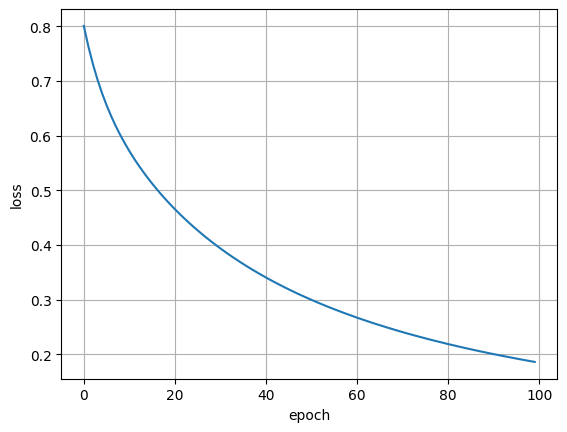

In [2]:
features = [[1.0, 2.0], [2.0, 1.0], [-1.0, -2.0]]
labels = [1, 0, 0]
initial_weights = [0.1, -0.2]
initial_bias = 0.0
learning_rate = 0.1
epochs = 100

updated_weights, updated_bias, nll_values = train_neuron(
    features, labels, initial_weights, initial_bias, learning_rate, epochs
)

plt.plot(nll_values)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)
plt.show()



### 1.2 Обучение на данных по двум годам



In [ ]:
train_x = pd.read_csv('data/songs/train_x.csv')
train_y = pd.read_csv('data/songs/train_y.csv')
year1 = 1940
year2 = 2007

data_year1 = train_y[train_y['year'] == year1]
data_year2 = train_y[train_y['year'] == year2]

ids_year1 = set(data_year1.iloc[:, 0].values)
ids_year2 = set(data_year2.iloc[:, 0].values)

features_years = []
labels_years = []

for idx, row in train_x.iterrows():
    song_id = row.iloc[0]
    if song_id in ids_year1:
        features_years.append([row.iloc[1], row.iloc[2]])
        labels_years.append(0)
    elif song_id in ids_year2:
        features_years.append([row.iloc[1], row.iloc[2]])
        labels_years.append(1)


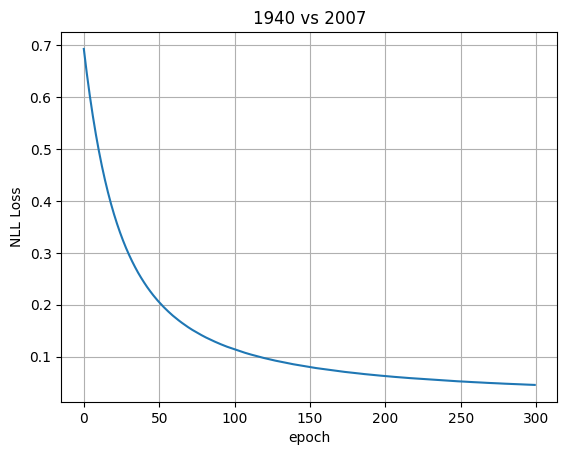

In [ ]:
features_years = np.array(features_years)
features_years = (features_years - features_years.mean(axis=0)) / (features_years.std(axis=0) + 1e-8)
features_years = features_years.tolist()

updated_weights, updated_bias, nll_values = train_neuron(
    features_years, labels_years, [0.0, 0.0], 0.0, 0.1, 100
)

plt.plot(nll_values)
plt.xlabel('epoch')
plt.ylabel('NLL Loss')
plt.title(f'{year1} vs {year2}')
plt.grid(True)
plt.show()



### 1.2.1 SGD



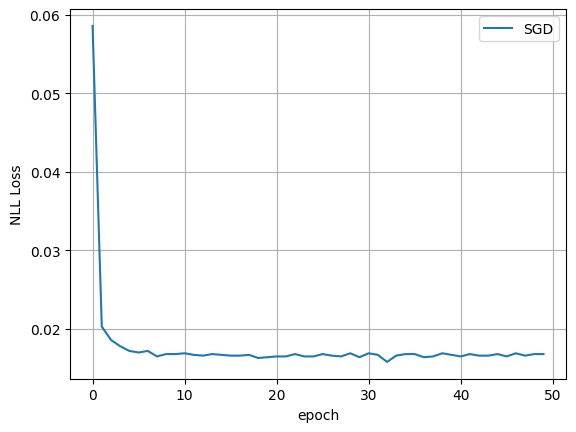

In [ ]:
weights_sgd, bias_sgd, nll_sgd = train_neuron(
    features_years, labels_years, [0.0, 0.0], 0.0, 0.1, 50, batch_size=1
)

plt.plot(nll_sgd)
plt.xlabel('epoch')
plt.ylabel('NLL Loss')
plt.title('SGD')
plt.grid(True)
plt.show()



## 2. autograd

In [6]:
a = Node(2)
b = Node(-3)
c = Node(10)
d = a + b * c
e = d.relu()
e.backward()
print(a, b, c, d, e)



Node(data=2.0, grad=0.0) Node(data=-3.0, grad=0.0) Node(data=10.0, grad=0.0) Node(data=-28.0, grad=0.0) Node(data=0.0, grad=1.0)


## 3. AdamW

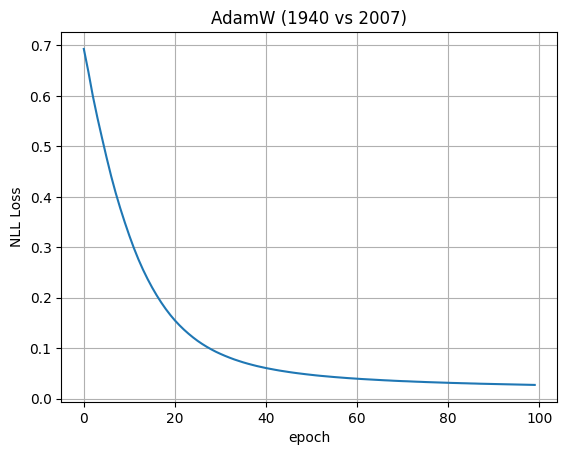

In [12]:
weights_adam = torch.tensor([0.0, 0.0], dtype=torch.float32)
bias_adam = torch.tensor([0.0], dtype=torch.float32)
optimizer = AdamW([weights_adam, bias_adam], lr=0.1, weight_decay=0.0)

updated_weights, updated_bias, nll_values = train_neuron_with_optimizer(
    features_years, labels_years, [0.0, 0.0], 0.0, optimizer, 100
)

plt.plot(nll_values)
plt.xlabel('epoch')
plt.ylabel('NLL Loss')
plt.title(f'AdamW ({year1} vs {year2})')
plt.grid(True)
plt.show()

